In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

puzzles = pd.read_csv("updated_scrape.csv")
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

In [48]:
puzzles = puzzles[~puzzles.Puzzle.isna()].copy()


In [49]:
(puzzles["Puzzle"][puzzles.Puzzle.apply(lambda x: "-" in x)]).value_counts().head(40)

Puzzle
ONE-WAY STREET                    4
ONE-HIT WONDER                    3
SOLD-OUT CONCERT                  3
WALL-TO-WALL CARPET               3
CAST-IRON SKILLET                 3
TUTTI-FRUTTI                      3
CHOCOLATE-COVERED STRAWBERRIES    3
COFFEE-TABLE BOOK                 3
LONG-DISTANCE RUNNER              3
NEXT-DOOR NEIGHBOR                3
HONEY-ROASTED PEANUTS             3
LATE-BREAKING NEWS                3
SHORT-ORDER COOK                  3
FRONT-PAGE NEWS                   3
HOME-COOKED MEAL                  3
DEEP-DISH APPLE PIE               3
RAZZLE-DAZZLE                     3
FULL-LENGTH MIRROR                3
SMASH-HIT BROADWAY MUSICAL        2
HONEY-GLAZED HAM                  2
SUN-DRIED TOMATOES                2
STRAIGHT-A STUDENT                2
FORGET-ME-NOTS                    2
PART-TIME STUDENT                 2
SLOW-ROASTED PRIME RIB            2
FIRST-CLASS TICKETS               2
HEART-SHAPED PENDANT              2
STAND-UP PADDLEBOARD 

In [44]:
puzzles["Puzzle"].value_counts().value_counts()

count
1    14139
2     2641
3      534
4      127
5        6
6        2
Name: count, dtype: int64

In [117]:
puzzles.head()

,Puzzle,Category,Date,Episode_Number,Round,first_letters,words,the,A_start,A_any,...,ZX_start,ZX_any,ZX_count,ZY_start,ZY_any,ZY_count,ZZ_start,ZZ_any,ZZ_count,test
0,ANYTHING IS POSSIBLE,Phrase,9/16/13,#5851,T1,"[A, I, P]","[ANYTHING, IS, POSSIBLE]",False,True,True,...,False,False,0,False,False,0,False,False,0,1
1,READY FREDDY,Rhyme Time,9/16/13,#5851,T2,"[R, F]","[READY, FREDDY]",False,False,True,...,False,False,0,False,False,0,False,False,0,1
2,COMING THROUGH WITH FLYING COLORS,What Are You Doing?,9/16/13,#5851,R1,"[C, T, W, F, C]","[COMING, THROUGH, WITH, FLYING, COLORS]",False,False,False,...,False,False,0,False,False,0,False,False,0,1
3,STICKY SITUATION COMEDY,Before & After,9/16/13,#5851,R2,"[S, S, C]","[STICKY, SITUATION, COMEDY]",False,False,True,...,False,False,0,False,False,0,False,False,0,1
4,FLOATING DOWN A LAZY RIVER,Fun & Games,9/16/13,#5851,R3*,"[F, D, A, L, R]","[FLOATING, DOWN, A, LAZY, RIVER]",False,True,True,...,False,False,0,False,True,1,False,False,0,1


In [50]:
puzzles["Puzzle"] = puzzles.Puzzle.str.replace("  ", "")
puzzles["first_letters"] = puzzles.Puzzle.apply(
    lambda x: [a[0] for a in str(x).split(" ")] if " " in x else [str(x)[0]]
)
puzzles["words"] = puzzles.Puzzle.apply(lambda x: [a for a in str(x).split(" ")] if " " in x else [str(x)[0]])
puzzles["the"] = puzzles.words.apply(lambda x: "THE" in x)
puzzles["a_full_word"] = puzzles.words.apply(lambda x: "A" in x)
puzzles['i_full_word'] = puzzles.words.apply(lambda x: "I" in x)
for l in letters:
    puzzles[f"{l}_start"] = puzzles["first_letters"].apply(lambda x: l in x)
    puzzles[f"{l}_any"] = puzzles["Puzzle"].apply(lambda x: l in x)
    puzzles[f"{l}_count"] = puzzles["Puzzle"].apply(lambda x: x.count(l))
for l in letters:
    for l2 in letters:
        puzzles[f"{l+l2}_start"] = puzzles["first_letters"].apply(lambda x: l+l2 in x)
        puzzles[f"{l+l2}_any"] = puzzles["Puzzle"].apply(lambda x: l+l2 in x)
        puzzles[f"{l+l2}_count"] = puzzles["Puzzle"].apply(lambda x: x.count(l+l2))

/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_8317/2559584950.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  puzzles[f"{l+l2}_start"] = puzzles["first_letters"].apply(lambda x: l+l2 in x)
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_8317/2559584950.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  puzzles[f"{l+l2}_any"] = puzzles["Puzzle"].apply(lambda x: l+l2 in x)
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_8317/2559584950.py:17: PerformanceWarning: DataFrame is highly fragmen

In [57]:
for l in letters:
    for length in range(4,13):
        vc = pd.Series([a for a in all_words if len(a) == length and a[0] == l]).value_counts()
        total_words = vc.sum().sum()
        top_words = vc/total_words
        top_words = top_words[top_words > .1]
        if top_words.shape[0]:
            print(l, length, top_words)

A 4 AWAY    0.357798
Name: count, dtype: float64
A 5 APPLE    0.165714
Name: count, dtype: float64
A 6 AROUND    0.165888
Name: count, dtype: float64
A 8 AMERICAN    0.104603
Name: count, dtype: float64
A 9 ADVENTURE    0.146552
Name: count, dtype: float64
A 11 ACHIEVEMENT    0.131148
ANNIVERSARY    0.131148
ADVERTISING    0.114754
Name: count, dtype: float64
A 12 ARCHITECTURE    0.333333
Name: count, dtype: float64
B 5 BEACH    0.105081
Name: count, dtype: float64
B 9 BEAUTIFUL    0.207951
BREAKFAST    0.122324
Name: count, dtype: float64
B 10 BASKETBALL    0.181818
BEACHFRONT    0.101010
Name: count, dtype: float64
B 11 BUTTERFLIES    0.234043
BLOCKBUSTER    0.170213
Name: count, dtype: float64
B 12 BREATHTAKING    0.263158
BREAKTHROUGH    0.175439
BUTTERSCOTCH    0.122807
BEST-SELLING    0.105263
Name: count, dtype: float64
C 4 CAKE    0.113798
Name: count, dtype: float64
C 9 CHOCOLATE    0.148402
Name: count, dtype: float64
C 10 CALIFORNIA    0.117241
COLLECTION    0.103448
Name: c

In [93]:
for l in letters:
    if l in ['J','K','Q','X','Z']: 
        continue
    for length in range(2,14):
        vc = pd.Series([a for a in all_words if len(a) == length and a[-1] == l]).value_counts()
        total_words = vc.sum().sum()
        top_words = vc/total_words
        top_words = top_words[top_words > .5]
        if top_words.shape[0] and vc.iloc[:top_words.shape[0]].values[0] > 30:
            print(l, length, top_words, vc.iloc[:top_words.shape[0]].values)

A 3 SEA    0.510638
Name: count, dtype: float64 [72]
A 10 CALIFORNIA    0.809524
Name: count, dtype: float64 [34]
D 3 AND    0.81563
Name: count, dtype: float64 [1075]
E 3 THE    0.883146
Name: count, dtype: float64 [3144]
F 2 OF    0.985201
Name: count, dtype: float64 [1398]
F 3 OFF    0.988235
Name: count, dtype: float64 [84]
L 3 ALL    0.808989
Name: count, dtype: float64 [144]
M 3 I'M    0.502041
Name: count, dtype: float64 [123]
N 2 IN    0.554982
Name: count, dtype: float64 [752]
O 2 TO    0.719037
Name: count, dtype: float64 [627]
P 2 UP    1.0
Name: count, dtype: float64 [184]
R 2 OR    1.0
Name: count, dtype: float64 [39]
R 3 FOR    0.59401
Name: count, dtype: float64 [357]
S 2 IS    0.688953
Name: count, dtype: float64 [237]
T 2 IT    0.638095
Name: count, dtype: float64 [268]
U 3 YOU    1.0
Name: count, dtype: float64 [317]
W 3 NEW    0.612378
Name: count, dtype: float64 [188]
Y 2 MY    0.837432
Name: count, dtype: float64 [613]


In [51]:
puzzles["the"].mean(), puzzles["a_full_word"].mean(), puzzles["i_full_word"].mean()

(0.1381849072632026, 0.09641795271131247, 0.01533814715182406)

In [121]:
pd.value_counts([a for a in all_words if 'II' in a]) / pd.value_counts([a for a in all_words if 'II' in a]).sum()

/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_67491/3540025934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts([a for a in all_words if 'II' in a]) / pd.value_counts([a for a in all_words if 'II' in a]).sum()
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_67491/3540025934.py:1: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts([a for a in all_words if 'II' in a]) / pd.value_counts([a for a in all_words if 'II' in a]).sum()
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_67491/3540025934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts([a for a in all_words if 'II' in a]) / pd.value_counts([a for a in all_words if 'II

HAWAII          0.333333
HAWAIIAN        0.311111
SKIING          0.266667
HAWAII'S        0.066667
WATER-SKIING    0.022222
Name: count, dtype: float64

In [128]:
pd.value_counts([a for a in all_words if 'OO' in a]).head(30) / len([a for a in all_words if 'EE' in a])

/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_67491/3108844409.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts([a for a in all_words if 'OO' in a]).head(30) / len([a for a in all_words if 'EE' in a])
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_67491/3108844409.py:1: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts([a for a in all_words if 'OO' in a]).head(30) / len([a for a in all_words if 'EE' in a])


GOOD            0.063636
SCHOOL          0.046104
FOOD            0.037662
ROOM            0.037013
BOOK            0.035714
POOL            0.031169
LOOKING         0.019481
LOOK            0.018831
HOLLYWOOD       0.018831
BOOTS           0.018182
FOOTBALL        0.016883
COOKIES         0.014935
DOOR            0.014286
TOO             0.013636
COOKIE          0.013636
OUTDOOR         0.012338
WOODEN          0.012338
NEIGHBORHOOD    0.012338
COOL            0.011688
BALLOONS        0.010390
FLOOR           0.009740
GOOSE           0.009740
SOOTHING        0.009091
MOON            0.008442
SMOOTH          0.008442
BOOKS           0.008442
SNOOZE          0.007792
WATERPROOF      0.007792
WOOL            0.007143
WOODS           0.007143
Name: count, dtype: float64

In [52]:
puzzles=puzzles.copy()

In [106]:
pd.Series(cat_pcts.index).apply(lambda x: len(x) > 3)

0     True
1     True
2    False
3     True
dtype: bool

In [53]:
all_words =  [item for sublist in puzzles.words for item in sublist]

In [116]:
for category in sorted(puzzles.Category.unique()):
    cat_words = [item for sublist in puzzles[puzzles.Category==category].words for item in sublist if len(item) > 3]
    cat_counts = pd.Series(cat_words).value_counts()
    cat_pcts = cat_counts / len(cat_words)
    if sum((cat_counts > 10) & (cat_pcts > .005) ) == 0:
        continue
    print(category)
    print(cat_pcts[(cat_counts > 10) & (cat_pcts > .004) 
          ])

Around the House
COLLECTION    0.017143
PILLOWS       0.016327
FAMILY        0.008980
CHAIR         0.008980
Name: count, dtype: float64
Before & After
YOUR       0.007614
DANCING    0.006164
LOVE       0.005076
LIFE       0.004714
FRENCH     0.004351
WITH       0.004351
HOME       0.004351
Name: count, dtype: float64
Character
CAPTAIN    0.034783
Name: count, dtype: float64
Event
PARTY         0.015984
TOUR          0.015485
DINNER        0.013986
NIGHT         0.011489
TRIP          0.009990
FESTIVAL      0.009990
FAMILY        0.009990
WEDDING       0.008991
WINNING       0.008991
FIRST         0.008492
VACATION      0.007992
WEEKEND       0.006993
OCCASION      0.006494
SALE          0.006494
SHOW          0.006494
HOLIDAY       0.006494
EXPERIENCE    0.006494
CONTEST       0.005994
GAME          0.005994
DATE          0.005994
ANNUAL        0.005994
ADVENTURE     0.005994
CEREMONY      0.005994
SEEING        0.005495
VICTORY       0.005495
GUIDED        0.005495
CRUISE        0.00

In [50]:
freq = pd.Series(all_words).value_counts() / len(all_words) 

In [54]:
for word in freq[freq.cumsum()<.5].index:
    print(word)

THE
A
OF
AND
IN
&
TO
MY
ON
FOR
I
YOU
IT
YOUR
WITH
IS
NEW
UP
OUT
AT
AN
ME
ALL
DAY
THIS
TIME
BE
I'M
BY
TAKING
MAKING
HOT
LIKE
PLAYING
FROM
HOME
FAMILY
GOOD
IT'S
AS
WE
LOVE
BEST
GREAT
BEACH
WORLD
THAT
WHAT
BACK
GOING
OFF
DINNER
CREAM
LITTLE
ONE
ARE
CAKE
LIFE
WAY
DO
HAVE
DOWN
BIG
PARTY
WATER
NIGHT
ICE
SEA
COFFEE
AROUND
SCHOOL
DON'T
RED
CHEESE
BEAUTIFUL
PARK
MOVIE
GAME
GO
BLUE
HAPPY
CHOCOLATE
PERFECT
MAN
FIRST
CITY
DANCING
BABY
S
FRENCH
SWEET
GETTING
TREE
OUR
ISLAND
HOUSE
FAVORITE
FOOD
CAN
NO
APPLE
BREAD
ROOM
TOUR
JUST
WARM
SHOW
CAR
BOOK
FRESH
GREEN
HIGH
RIGHT
FRIENDS
FUN
PIE
WHITE
TAKE
WILD
WEDDING
B
STATE
ROCK
LONG
TOP
READING
LET'S
THINGS
COME
WILL
POOL
TELEVISION
BREAK
FISH
SHOPPING
WORK
GET
TWO
OFFICE
NEVER
VACATION
DOUBLE
BUSINESS
STARS
SO
BALL
RIDING
GRAND
POTATO
MUSIC
STAR
BOWL
SALAD
GOLD
SOME
TEAM
AIR
OLD
MAKE
PLACE
NATIONAL
CHICKEN
OVER
PAPER
PLAY
WEATHER
OCEAN
TEA
MOUNTAIN
MONEY
TABLE
NOT
FULL
THROUGH
WAS
BUILDING
THAT'S
BREAKFAST
FLYING
WHERE
SETTING
OR
AWAY
WALKING
DREAM
BOARD


In [110]:
pd.Series([a for a in all_words if len(a) == 4]).value_counts().head(30)/ len([a for a in all_words if len(a) == 4])

YOUR    0.023202
WITH    0.022744
THIS    0.012106
TIME    0.011831
LIKE    0.009905
FROM    0.009629
HOME    0.009538
GOOD    0.008988
IT'S    0.008988
LOVE    0.008712
BEST    0.008621
WHAT    0.007979
THAT    0.007979
BACK    0.007887
CAKE    0.007337
LIFE    0.007153
HAVE    0.006970
DOWN    0.006878
PARK    0.006236
GAME    0.006053
BLUE    0.005961
CITY    0.005778
BABY    0.005686
TREE    0.005503
FOOD    0.005319
TOUR    0.005227
ROOM    0.005227
WARM    0.005136
JUST    0.005136
SHOW    0.005044
Name: count, dtype: float64

In [112]:
pd.Series([a for a in all_words if len(a) == 6]).value_counts().head(30)/ len([a for a in all_words if len(a) == 6])

TAKING    0.013230
MAKING    0.013118
FAMILY    0.011451
DINNER    0.009227
LITTLE    0.009116
COFFEE    0.008004
AROUND    0.007893
SCHOOL    0.007893
CHEESE    0.007560
FRENCH    0.006782
ISLAND    0.006559
THINGS    0.005447
DOUBLE    0.005114
OFFICE    0.005114
RIDING    0.005003
POTATO    0.005003
THAT'S    0.004447
FLYING    0.004336
STREET    0.004225
SECRET    0.004225
TRAVEL    0.004225
GOLDEN    0.004113
GARDEN    0.004002
SUMMER    0.003891
CENTER    0.003780
YOU'RE    0.003669
BEAUTY    0.003669
NATURE    0.003669
PLAYER    0.003558
SECOND    0.003558
Name: count, dtype: float64

In [55]:
pd.Series([a for a in all_words if len(a) == 3]).value_counts().head(30)

THE    3142
AND    1032
FOR     318
YOU     300
NEW     183
OUT     178
ALL     146
DAY     123
HOT     105
I'M     104
BIG      85
ONE      81
WAY      80
ICE      79
OFF      78
ARE      72
SEA      67
RED      65
OUR      65
MAN      59
CAN      58
PIE      52
FUN      50
OLD      49
CAR      48
GET      48
AIR      41
TWO      41
TEA      40
NOT      40
Name: count, dtype: int64

In [39]:
(pd.Series([a for a in all_words if len(a) == 12]).value_counts().head(30) / len([a for a in all_words if len(a) == 12]))

PROFESSIONAL    0.036199
NEIGHBORHOOD    0.028658
BREATHTAKING    0.022624
CONVERSATION    0.019608
MARSHMALLOWS    0.018100
RESERVATIONS    0.016591
ARCHITECTURE    0.015083
STRAWBERRIES    0.015083
BREAKTHROUGH    0.015083
PRESIDENTIAL    0.015083
PHILADELPHIA    0.013575
CONSTRUCTION    0.013575
SUBSCRIPTION    0.012066
INDEPENDENCE    0.012066
HEARTWARMING    0.012066
PERSONALIZED    0.012066
CHEESEBURGER    0.012066
BUTTERSCOTCH    0.010558
PHOTOGRAPHER    0.010558
CHAMPIONSHIP    0.010558
REFRIGERATOR    0.010558
HEART-SHAPED    0.010558
DESTINATIONS    0.009050
PENNSYLVANIA    0.009050
BEST-SELLING    0.009050
WORLD-FAMOUS    0.009050
FRANKENSTEIN    0.009050
UNBELIEVABLE    0.009050
TEMPERATURES    0.007541
MOISTURIZING    0.006033
Name: count, dtype: float64

In [62]:
for length in range(1,14):

    print(length)

    print("----")
    print(pd.Series([a for a in all_words if len(a) == length]).value_counts().head(30) / len([a for a in all_words if len(a) == length]))

    print("====")


1
----
A    0.584795
&    0.199387
I    0.099415
S    0.018658
B    0.013645
C    0.010304
P    0.010304
T    0.006962
H    0.006405
M    0.006405
G    0.006126
W    0.005291
D    0.005291
L    0.005013
R    0.004177
F    0.003342
J    0.002785
E    0.002506
O    0.001949
V    0.001949
N    0.001949
Z    0.001671
Q    0.000557
K    0.000557
Y    0.000278
U    0.000278
Name: count, dtype: float64
====
2
----
OF    0.232838
IN    0.131703
MY    0.114585
TO    0.104978
ON    0.083843
IT    0.045590
IS    0.039301
UP    0.031616
AT    0.029694
AN    0.025852
ME    0.021485
BE    0.021135
BY    0.016943
WE    0.015546
AS    0.014847
GO    0.012227
DO    0.011878
NO    0.010655
SO    0.008559
OR    0.006638
AM    0.003668
IF    0.003319
LA    0.001921
US    0.001747
OH    0.001397
TV    0.001397
HE    0.001397
HI    0.001048
OZ    0.000873
DE    0.000349
Name: count, dtype: float64
====
3
----
THE    0.345465
AND    0.113469
FOR    0.034964
YOU    0.032985
NEW    0.020121
OUT    0.019571
ALL

In [60]:
print(pd.Series([a for a in all_words if  "'" in a]).value_counts().head(30) / len([a for a in all_words if "'" in a]))


I'M            0.118451
IT'S           0.112756
DON'T          0.079727
LET'S          0.062642
THAT'S         0.043280
YOU'RE         0.038724
I'VE           0.035308
WE'RE          0.034169
I'LL           0.033030
THERE'S        0.030752
CAN'T          0.029613
WON'T          0.020501
WHAT'S         0.019362
WORLD'S        0.009112
AMERICA'S      0.009112
YOU'LL         0.009112
COULDN'T       0.007973
YOU'VE         0.007973
FARMERS'       0.007973
DOESN'T        0.006834
WE'VE          0.006834
I'D            0.006834
DIDN'T         0.005695
CAPTAIN'S      0.005695
WE'LL          0.005695
WHERE'S        0.005695
WINNER'S       0.004556
WOMEN'S        0.004556
VALENTINE'S    0.004556
WHO'S          0.004556
Name: count, dtype: float64


In [61]:
print(pd.Series([a for a in all_words if  "-" in a]).value_counts().head(30) / len([a for a in all_words if "-" in a]))



CUSTOM-MADE          0.008909
SOLD-OUT             0.008909
FLIP-FLOPS           0.008909
BEST-SELLING         0.007795
AWARD-WINNING        0.007795
HOME-COOKED          0.006682
WORLD-FAMOUS         0.006682
PICTURE-PERFECT      0.006682
ONE-WAY              0.006682
STAND-UP             0.006682
OLD-FASHIONED        0.006682
WALL-TO-WALL         0.005568
DEEP-SEA             0.005568
HOT-AIR              0.005568
CHOCOLATE-COVERED    0.005568
LAID-BACK            0.005568
THANK-YOU            0.005568
DEEP-DISH            0.005568
WALK-IN              0.005568
HEART-SHAPED         0.005568
FOUR-LEAF            0.005568
ALL-STAR             0.005568
DRIVE-IN             0.005568
WELL-DESERVED        0.005568
THREE-CHEESE         0.005568
PING-PONG            0.005568
GLUTEN-FREE          0.004454
CLOSE-KNIT           0.004454
FULL-LENGTH          0.004454
YEAR-ROUND           0.004454
Name: count, dtype: float64


In [27]:
pd.Series([a for a in all_words if len(a) == 2]).value_counts().head(30)

OF    1398
IN     752
TO     627
MY     613
ON     454
IT     268
IS     237
UP     184
AT     152
AN     149
ME     146
BE     123
BY     119
WE      96
AS      96
DO      76
GO      65
NO      58
SO      46
OR      39
IF      21
AM      20
LA      12
US      11
HE       8
OH       7
OZ       6
HI       6
TV       6
FE       4
Name: count, dtype: int64

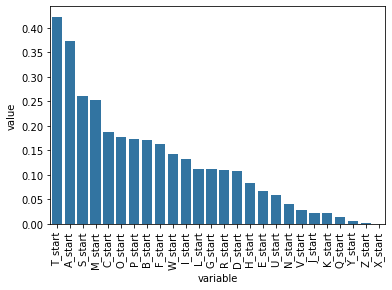

In [43]:
sns.barplot(
    data=puzzles[puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("Category")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)

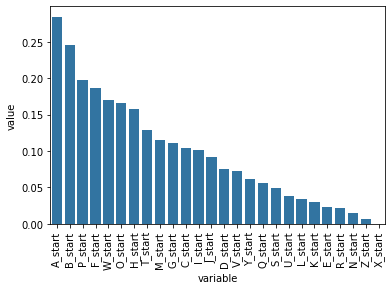

In [44]:
puzzles["test"] = 1
sns.barplot(
    data=puzzles[puzzles.Round.isin(["BR"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)


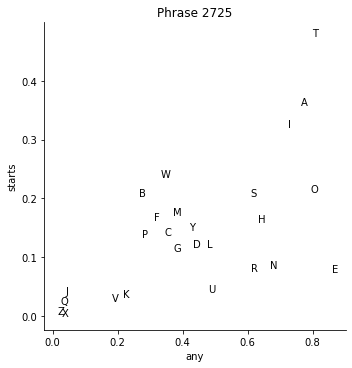

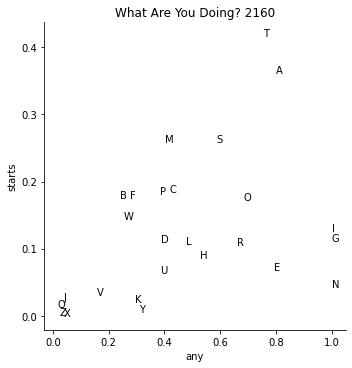

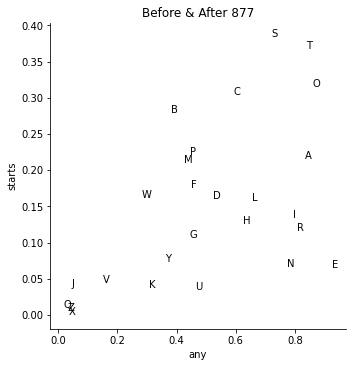

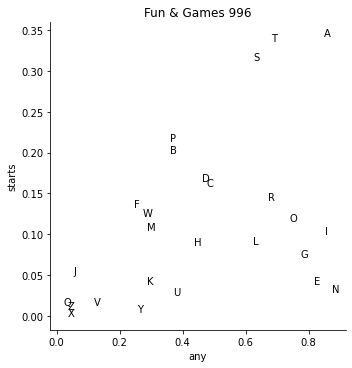

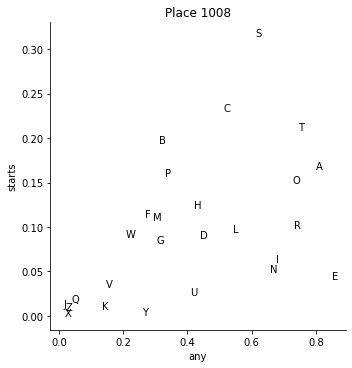

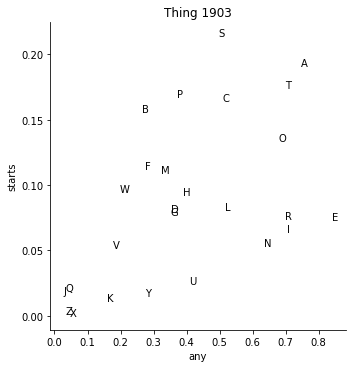

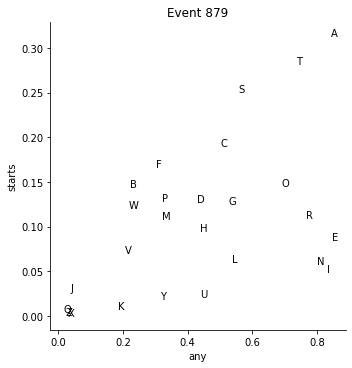

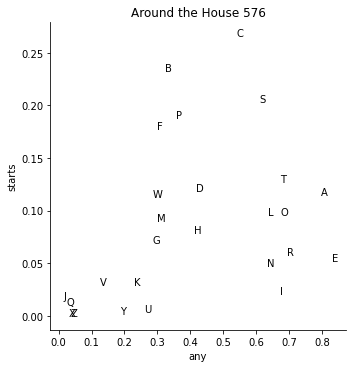

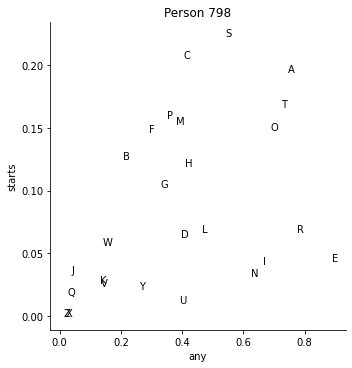

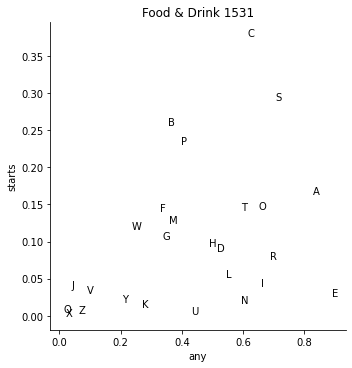

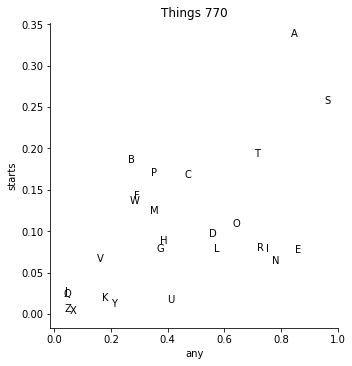

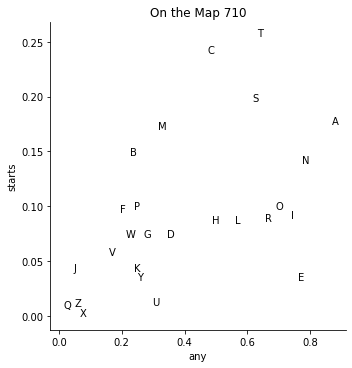

In [79]:
for cat in puzzles.Category.unique():
    if puzzles.Category.value_counts()[cat] < 500:
        continue
        
    starts = (
        puzzles[puzzles.Category == cat]
        .groupby("test")
        .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
        .melt()
        .sort_values("value", ascending=False)
    )
    starts["variable"] = starts.variable.str.replace("_start", "")
    starts["starts"] = starts.pop("value")
    
    anys = (
        puzzles[puzzles.Category == cat]
        .groupby("test")
        .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
        .melt()
        .sort_values("value", ascending=False)
    )
    anys["variable"] = anys.variable.str.replace("_any", "")
    anys["any"] = anys.pop("value")
    
    merged = anys.merge(starts)
    sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
    for r in merged.itertuples():
        plt.text(r.any, r.starts, r.variable)
    plt.title(cat + ' ' + str(puzzles.Category.value_counts()[cat]))
    plt.show()
    plt.close()

2725

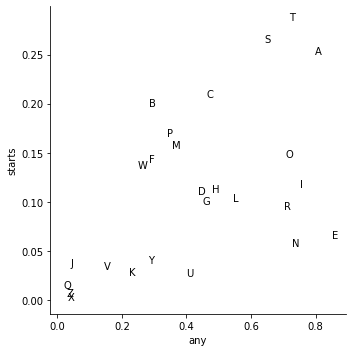

In [46]:
starts = (
    puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles.groupby("test")
    
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

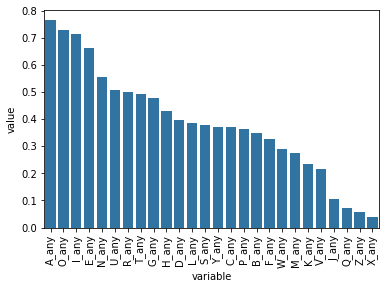

In [33]:
sns.barplot(
    data=puzzles[puzzles.Round.isin(["BR"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)


In [36]:
puzzles['test']=1

/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_67491/525585196.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  puzzles['test']=1


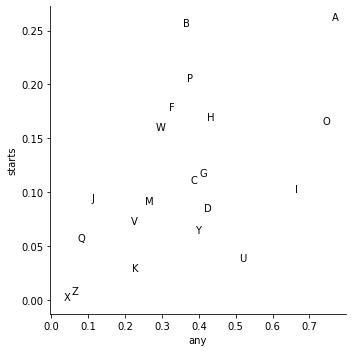

In [37]:
starts = (
    puzzles[puzzles.Round.isin(["BR"]) & ~puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.Round.isin(["BR"]) & ~puzzles.Category.isin(["What Are You Doing?"])]
    
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    if r.variable in "LSRTNE":
        continue
    plt.text(r.any, r.starts, r.variable)

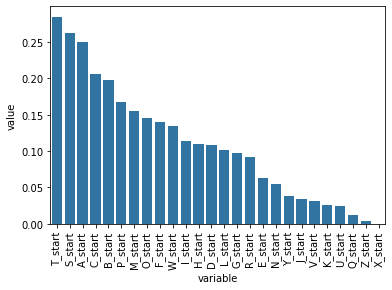

In [37]:
puzzles["test"] = 1
sns.barplot(
    data=puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)


In [ ]:
puzzles[puzzles.Category.isin(puzzles.Category.value_counts().index[:50])].groupby("Category").mean(numeric_only=True)[
    [f"{l}_start" for l in letters]
].reset_index()[puzzles.Category.value_counts().index.values]

KeyError: "None of [Index(['Phrase', 'What Are You Doing?', 'Thing', 'Food & Drink', 'Place',\n       'Fun & Games', 'Event', 'Before & After', 'Person', 'Things',\n       ...\n       'Tennis _____', '_____ School', 'If the Shoe Fits', 'World Capitals',\n       'On the Water', '_____ Boat', 'Have A Cookie', 'Coastal _____',\n       'Artificial _____', 'Vehicles'],\n      dtype='object', length=712)] are in the [columns]"

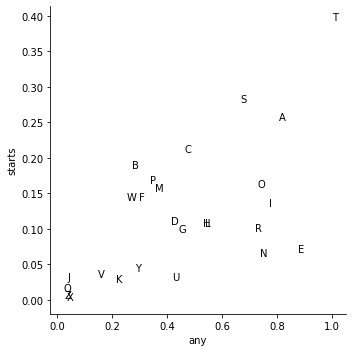

In [ ]:
starts = (
    puzzles[puzzles.T_any]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.T_any]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

In [15]:
# two letter frequency
means = []
for l in letters:
    for l2 in letters:
        means.append([l, l2,puzzles[f"{l+l2}_any"].mean(),puzzles[f"{l}_any"].mean(),puzzles[f"{l2}_any"].mean() ])


In [16]:
means_df = pd.DataFrame(means, columns=['l1','l2','bigram_mean','l1_mean','l2_mean'])

In [18]:
means_df['pct_increase'] = means_df['bigram_mean'] / means_df['l1_mean'] / means_df['l2_mean'] 

In [22]:
means_df.sort_values('bigram_mean',ascending=False).head(50)

,l1,l2,bigram_mean,l1_mean,l2_mean,pct_increase
221,I,N,0.367728,0.747230,0.728550,0.675481
344,N,G,0.273954,0.728550,0.446716,0.841757
121,E,R,0.245538,0.851481,0.703750,0.409757
501,T,H,0.217772,0.715988,0.478561,0.635564
13,A,N,0.206740,0.796922,0.728550,0.356081
186,H,E,0.204005,0.478561,0.851481,0.500643
377,O,N,0.175219,0.710703,0.728550,0.338403
446,R,E,0.170815,0.703750,0.851481,0.285058
17,A,R,0.157280,0.796922,0.703750,0.280439
487,S,T,0.153711,0.645158,0.715988,0.332761


In [23]:
means_df.sort_values('pct_increase',ascending=False).head(50)

,l1,l2,bigram_mean,l1_mean,l2_mean,pct_increase
675,Z,Z,0.005980,0.028693,0.028693,7.263049
436,Q,U,0.020674,0.020674,0.400779,2.495142
344,N,G,0.273954,0.728550,0.446716,0.841757
127,E,X,0.019701,0.851481,0.032587,0.710000
254,J,U,0.011310,0.041163,0.400779,0.685602
221,I,N,0.367728,0.747230,0.728550,0.675481
62,C,K,0.069021,0.466231,0.223196,0.663281
550,V,E,0.081166,0.148658,0.851481,0.641228
501,T,H,0.217772,0.715988,0.478561,0.635564
186,H,E,0.204005,0.478561,0.851481,0.500643


In [24]:
means_df.sort_values('pct_increase',ascending=False).head(50)

,l1,l2,bigram_mean,l1_mean,l2_mean,pct_increase
675,Z,Z,0.005980,0.028693,0.028693,7.263049
436,Q,U,0.020674,0.020674,0.400779,2.495142
344,N,G,0.273954,0.728550,0.446716,0.841757
127,E,X,0.019701,0.851481,0.032587,0.710000
254,J,U,0.011310,0.041163,0.400779,0.685602
221,I,N,0.367728,0.747230,0.728550,0.675481
62,C,K,0.069021,0.466231,0.223196,0.663281
550,V,E,0.081166,0.148658,0.851481,0.641228
501,T,H,0.217772,0.715988,0.478561,0.635564
186,H,E,0.204005,0.478561,0.851481,0.500643
